#Introducción
##Descripción del problema


* ¿La IA realmente mejora los ingresos o solo reduce costos?
* ¿Qué industrias tienen mayor ROI?
* ¿Qué tan fuerte es la relación entre adopción de IA y productividad?
* ¿Existe un punto de saturación?
* ¿Las empresas grandes vs pequeñas difieren?

##Objetivo
Evaluar el impacto real de la inteligencia artificial en el desempeño empresarial usando KPIs como:

* revenue_growth_percent
* cost_reduction_percent
* productivity_change_percent
* ai_adoption_rate


#Desarrollo del Proyecto

##Importación de Librerías y Carga de Datos

In [ ]:
#Importación de Librerias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
import statsmodels.formula.api as smf

In [ ]:
# Importación de Data
import kagglehub
path = kagglehub.dataset_download("mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset")

Using Colab cache for faster access to the 'global-ai-adoption-and-workforce-impact-dataset' dataset.


##Carga de la Base de Datos

In [ ]:
# Lectura del Data
df_ia_read = pd.read_csv("/kaggle/input/global-ai-adoption-and-workforce-impact-dataset/ai_company_adoption.csv")
df_ia = df_ia_read.copy()
df_ia

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,159996,COMP-10000,2025,Q4,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,19.01,1292,1027,1766,9.44,9.52,62,5.68,McKinsey Report,Phone Interview
149996,159997,COMP-10000,2026,Q1,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,15.56,466,883,803,10.65,6.94,56,5.57,Internal Corporate Survey,Research Compilation
149997,159998,COMP-10000,2026,Q2,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,13.38,1360,1474,1779,5.52,0.32,48,7.56,WEF Survey,API Scrape
149998,159999,COMP-10000,2026,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,12.75,1358,887,1648,11.87,7.85,69,6.00,WEF Survey,Research Compilation


In [ ]:
df_ia.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [ ]:
df_ia.shape

(150000, 43)

In [ ]:
df_ia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  object 
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  object 
 4   country                      150000 non-null  object 
 5   region                       150000 non-null  object 
 6   industry                     150000 non-null  object 
 7   company_size                 150000 non-null  object 
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  object 
 13 

##Exploración de los Datos

In [ ]:
# Sacamos una visión general
df_ia.describe().T

,count,mean,std,min,25%,50%,75%,max
response_id,150000.0,79961.106207,46158.813039,1.00,40020.75,79937.500,119913.250,160000.000
survey_year,150000.0,2024.500987,1.118013,2023.00,2024.00,2025.000,2026.000,2026.000
num_employees,150000.0,2342.376580,4754.424755,10.00,69.00,349.000,884.000,19970.000
annual_revenue_usd_millions,150000.0,1180.345751,2391.471420,1.01,33.88,184.160,444.150,9996.730
company_founding_year,150000.0,2005.993767,9.473220,1990.00,1998.00,2006.000,2014.000,2022.000
company_age,150000.0,18.507220,9.539367,1.00,10.00,18.000,27.000,36.000
ai_adoption_rate,150000.0,36.414726,14.544096,0.00,26.43,36.320,46.200,100.000
years_using_ai,150000.0,4.931580,2.429316,0.00,3.00,5.000,7.000,10.000
num_ai_tools_used,150000.0,2.315120,0.946826,1.00,2.00,2.000,3.000,6.000
ai_projects_active,150000.0,6.270693,3.500142,0.00,4.00,6.000,9.000,20.000


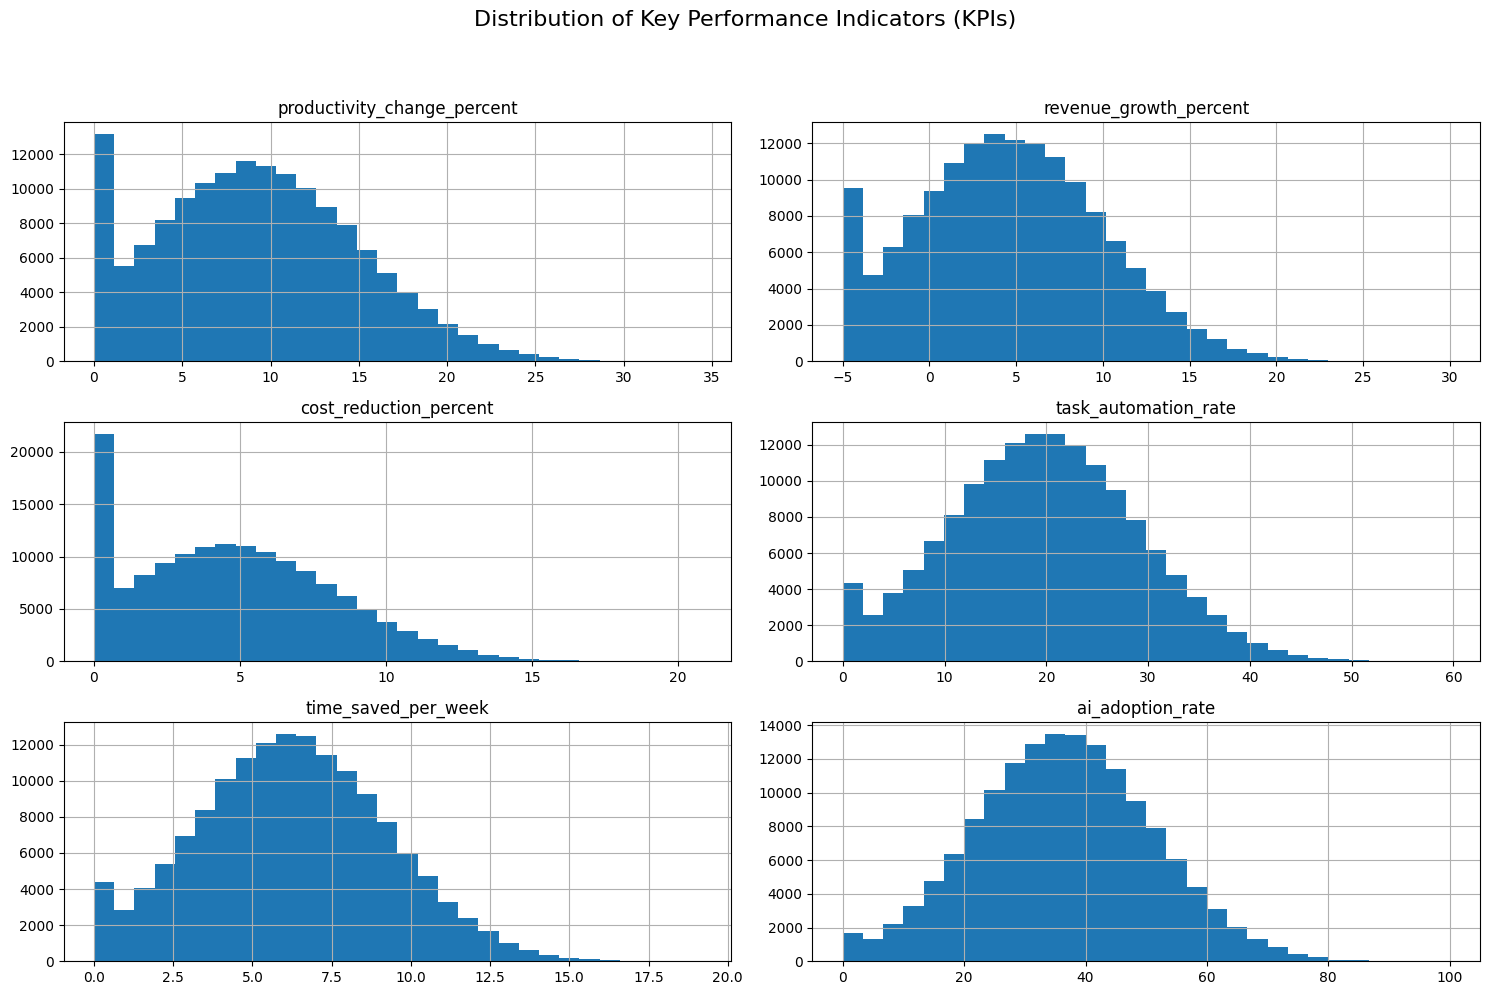

In [ ]:
# Distribución de los KPI
kpis = [
    'productivity_change_percent',
    'revenue_growth_percent',
    'cost_reduction_percent',
    'task_automation_rate',
    'time_saved_per_week',
    'ai_adoption_rate'
]

fig = df_ia[kpis].hist(figsize=(15, 10), bins=30)
plt.suptitle('Distribution of Key Performance Indicators (KPIs)', y=1.02, fontsize=16) # Add a main title
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

## Limpieza de Datos


###Conversión de variables

In [ ]:
# Convertimos los objetos en categorias
for col in df_ia.select_dtypes(include='object').columns:
    df_ia[col] = df_ia[col].astype('category')

# Convertimos el float 64 en 32
for col in df_ia.select_dtypes(include='float64').columns:
    df_ia[col] = df_ia[col].astype('float32')

# Convertimos los int 64 a 32
for col in df_ia.select_dtypes(include='int64').columns:
    df_ia[col] = df_ia[col].astype('int32')

df_ia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   response_id                  150000 non-null  int32   
 1   company_id                   150000 non-null  category
 2   survey_year                  150000 non-null  int32   
 3   quarter                      150000 non-null  category
 4   country                      150000 non-null  category
 5   region                       150000 non-null  category
 6   industry                     150000 non-null  category
 7   company_size                 150000 non-null  category
 8   num_employees                150000 non-null  int32   
 9   annual_revenue_usd_millions  150000 non-null  float32 
 10  company_founding_year        150000 non-null  int32   
 11  company_age                  150000 non-null  int32   
 12  company_age_group            150000 non-null

In [ ]:
# Visión sobre las categorías
cat_cols = df_ia.select_dtypes(include='category').columns

for col in cat_cols:
    print(f"\nCategory: {col}")
    print(df_ia[col].value_counts(normalize=True).head(5))


Category: company_id
company_id
COMP-09978    0.000107
COMP-00001    0.000107
COMP-09990    0.000107
COMP-09985    0.000107
COMP-00012    0.000107
Name: proportion, dtype: float64

Category: quarter
quarter
Q4    0.250280
Q3    0.249947
Q2    0.249927
Q1    0.249847
Name: proportion, dtype: float64

Category: country
country
France         0.037580
Japan          0.037527
South Korea    0.036287
Germany        0.035513
Chile          0.034600
Name: proportion, dtype: float64

Category: region
region
Asia             0.331513
Europe           0.272233
South America    0.132727
Africa           0.131913
Oceania          0.066680
Name: proportion, dtype: float64

Category: industry
industry
Technology       0.140713
Finance          0.134440
Healthcare       0.124280
Manufacturing    0.116673
Retail           0.109180
Name: proportion, dtype: float64

Category: company_size
company_size
SME           0.42578
Startup       0.37790
Enterprise    0.19632
Name: proportion, dtype: float64

Ca

###Imputación y Normalización de los Datos

In [ ]:
# Identificar y tratar outliers usando el método IQR (capping)
for col in kpis:
    Q1 = df_ia[col].quantile(0.25)
    Q3 = df_ia[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Aplicar capping (limitar los valores a los límites inferior y superior)
    df_ia[col] = df_ia[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled for KPIs using IQR capping.")

# Normalización de los KPIs usando MinMaxScaler
scaler = MinMaxScaler()
df_ia[kpis] = scaler.fit_transform(df_ia[kpis])

print("KPIs normalized using MinMaxScaler.")

df_ia[kpis].head()

Outliers handled for KPIs using IQR capping.
KPIs normalized using MinMaxScaler.


,productivity_change_percent,revenue_growth_percent,cost_reduction_percent,task_automation_rate,time_saved_per_week,ai_adoption_rate
0,0.105180,0.307818,0.645271,0.432571,0.445521,0.403006
1,0.229014,0.399918,0.000000,0.582982,0.617088,0.359238
2,0.275451,0.731478,0.665073,0.494112,0.525078,0.415793
3,0.211153,0.539910,0.000000,0.063764,0.218609,0.145277
4,0.250843,0.667212,0.615910,0.409687,0.486337,0.440182


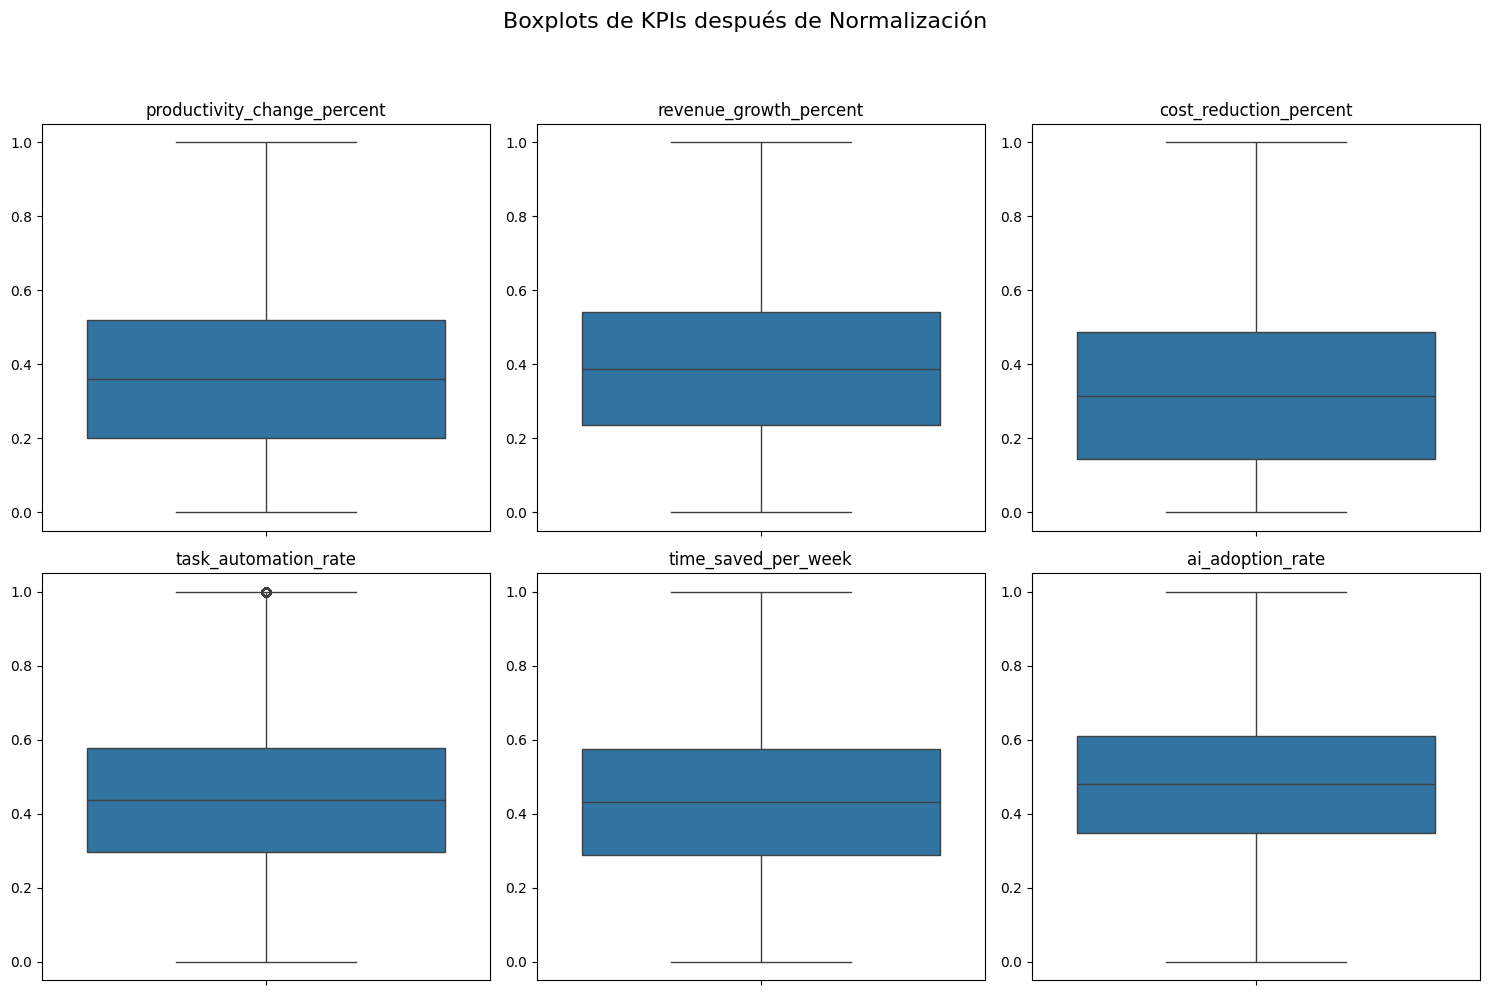

In [ ]:
plt.figure(figsize=(15, 10))

# Preparar datos para boxplot de los KPIs normalizados
df_normalized_kpis = df_ia[kpis]

plt.suptitle('Boxplots de KPIs después de Normalización', y=1.02, fontsize=16)

for i, col in enumerate(df_normalized_kpis.columns):
    plt.subplot(2, 3, i + 1) # Ajusta el tamaño de la cuadrícula según el número de KPIs
    sns.boxplot(y=df_normalized_kpis[col])
    plt.title(col)
    plt.ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

##Análisis de los Datos

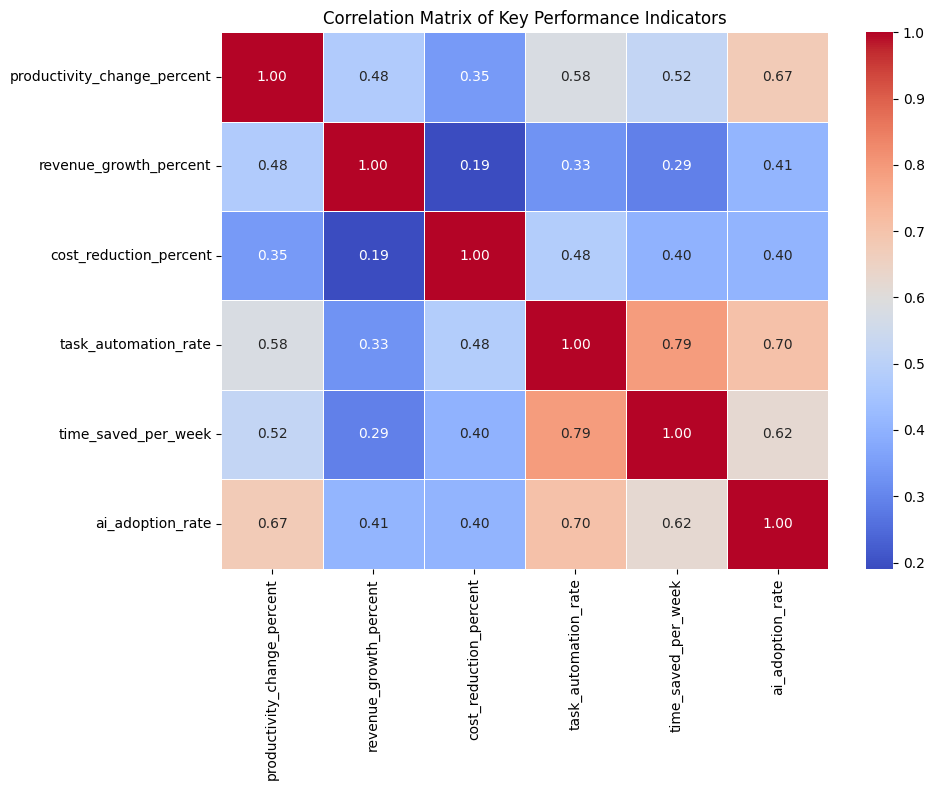

In [ ]:
# Generamos las Correlaciones
corr = df_ia[kpis].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Performance Indicators')
plt.tight_layout()
plt.show()

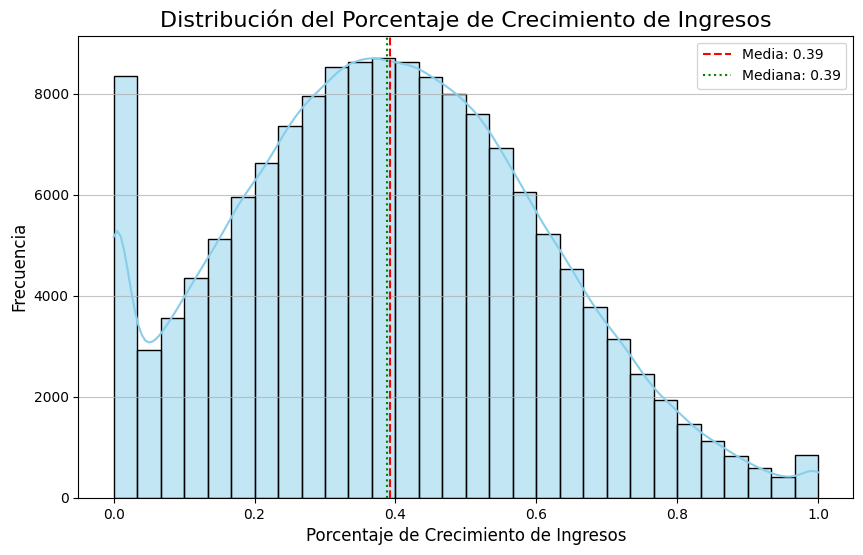


--- Estadísticas Descriptivas para 'revenue_growth_percent' ---
count    150000.000000
mean          0.392974
std           0.216936
min           0.000000
25%           0.236594
50%           0.388047
75%           0.541957
max           1.000000
Name: revenue_growth_percent, dtype: float64
Skewness: 0.19
Kurtosis: -0.42

La media de crecimiento de ingresos es positiva, lo que sugiere un crecimiento general.
La distribución es relativamente simétrica, o con un sesgo leve.


In [ ]:
# Análisis univariable de 'revenue_growth_percent'
plt.figure(figsize=(10, 6))
sns.histplot(df_ia['revenue_growth_percent'], kde=True, bins=30, color='skyblue')

# Añadir líneas para la media y la mediana
mean_growth = df_ia['revenue_growth_percent'].mean()
median_growth = df_ia['revenue_growth_percent'].median()

plt.axvline(mean_growth, color='red', linestyle='dashed', linewidth=1.5, label=f'Media: {mean_growth:.2f}')
plt.axvline(median_growth, color='green', linestyle='dotted', linewidth=1.5, label=f'Mediana: {median_growth:.2f}')

plt.title('Distribución del Porcentaje de Crecimiento de Ingresos', fontsize=16)
plt.xlabel('Porcentaje de Crecimiento de Ingresos', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\n--- Estadísticas Descriptivas para 'revenue_growth_percent' ---")
print(df_ia['revenue_growth_percent'].describe())
print(f"Skewness: {df_ia['revenue_growth_percent'].skew():.2f}")
print(f"Kurtosis: {df_ia['revenue_growth_percent'].kurtosis():.2f}")

# Interpretación básica
if mean_growth > 0:
    print("\nLa media de crecimiento de ingresos es positiva, lo que sugiere un crecimiento general.")
else:
    print("\nLa media de crecimiento de ingresos es negativa o cero, lo que sugiere un estancamiento o decrecimiento general.")

if df_ia['revenue_growth_percent'].skew() > 0.5:
    print("La distribución está sesgada positivamente (hacia la derecha), lo que indica que hay más empresas con crecimientos leves, pero algunas con crecimientos muy altos.")
elif df_ia['revenue_growth_percent'].skew() < -0.5:
    print("La distribución está sesgada negativamente (hacia la izquierda), lo que indica que hay más empresas con decrecimientos, y algunas con decrecimientos muy bajos.")
else:
    print("La distribución es relativamente simétrica, o con un sesgo leve.")

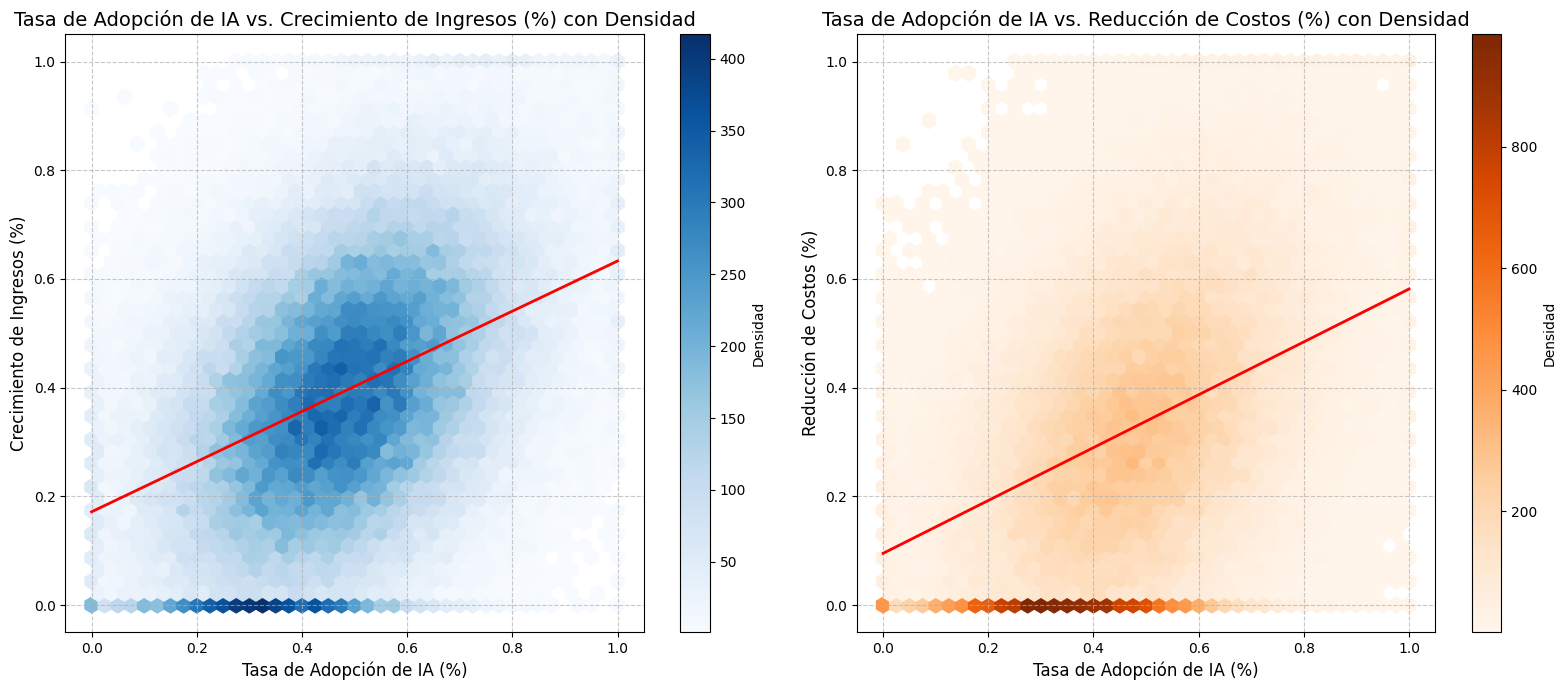

In [ ]:
plt.figure(figsize=(16, 7))

# Subtrama 1: Tasa de Adopción de IA vs. Crecimiento de Ingresos (%)
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primera gráfica
# Gráfico Hexbin
hb1 = plt.hexbin(x=df_ia['ai_adoption_rate'], y=df_ia['revenue_growth_percent'], gridsize=40, cmap='Blues', mincnt=1) # mincnt=1 para evitar dibujar hexágonos vacíos
plt.colorbar(hb1, label='Densidad')
# Línea de regresión
sns.regplot(x='ai_adoption_rate', y='revenue_growth_percent', data=df_ia, scatter=False, color='red', line_kws={'lw': 2})
plt.title('Tasa de Adopción de IA vs. Crecimiento de Ingresos (%) con Densidad', fontsize=14)
plt.xlabel('Tasa de Adopción de IA (%)', fontsize=12)
plt.ylabel('Crecimiento de Ingresos (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Subtrama 2: Tasa de Adopción de IA vs. Reducción de Costos (%)
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segunda gráfica
# Gráfico Hexbin
hb2 = plt.hexbin(x=df_ia['ai_adoption_rate'], y=df_ia['cost_reduction_percent'], gridsize=40, cmap='Oranges', mincnt=1) # mincnt=1 para evitar dibujar hexágonos vacíos
plt.colorbar(hb2, label='Densidad')
# Línea de regresión
sns.regplot(x='ai_adoption_rate', y='cost_reduction_percent', data=df_ia, scatter=False, color='red', line_kws={'lw': 2})
plt.title('Tasa de Adopción de IA vs. Reducción de Costos (%) con Densidad', fontsize=14)
plt.xlabel('Tasa de Adopción de IA (%)', fontsize=12)
plt.ylabel('Reducción de Costos (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 2. Cálculo del ROI de IA
df_ia['roi_ai'] = df_ia['revenue_growth_percent'] + df_ia['cost_reduction_percent']

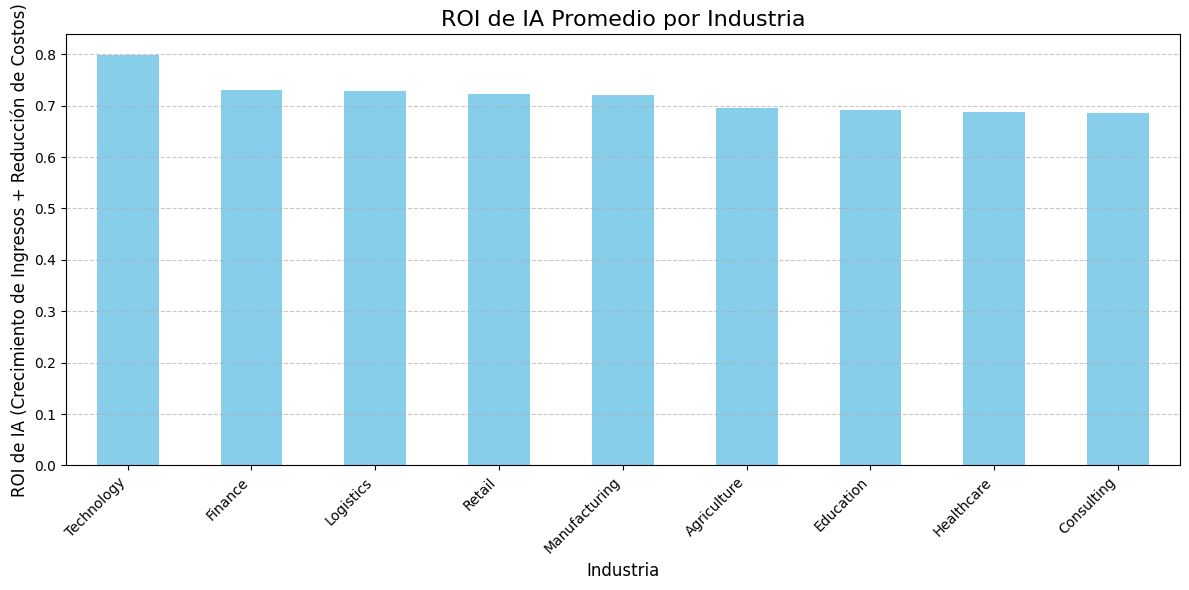

In [ ]:
# Asegurémonos de que 'roi_ai' esté calculado en df_ia
df_ia['roi_ai'] = df_ia['revenue_growth_percent'] + df_ia['cost_reduction_percent']

# ROI por industria
roi_industry = df_ia.groupby('industry', observed=False)['roi_ai'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6)) # Aumentar tamaño para mejor visibilidad
roi_industry.plot(kind='bar', color='skyblue') # Añadir color
plt.title('ROI de IA Promedio por Industria', fontsize=16) # Título más descriptivo
plt.xlabel('Industria', fontsize=12)
plt.ylabel('ROI de IA (Crecimiento de Ingresos + Reducción de Costos)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas del eje X para evitar solapamiento
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir cuadrícula para facilitar la lectura
plt.tight_layout() # Ajustar el diseño para evitar el recorte de elementos
plt.show()

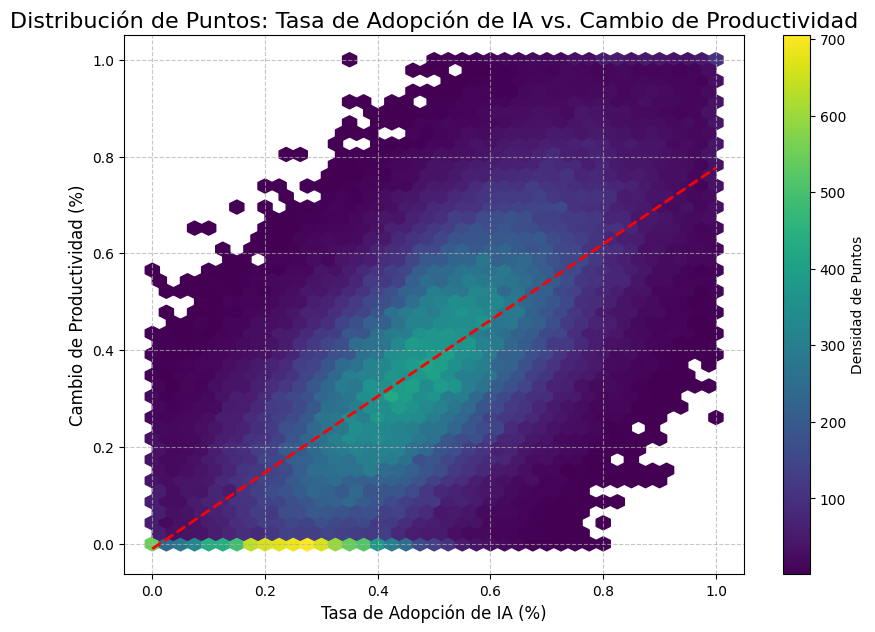

In [ ]:
plt.figure(figsize=(10, 7))
# Gráfico Hexbin para la distribución de puntos
hb = plt.hexbin(x=df_ia['ai_adoption_rate'], y=df_ia['productivity_change_percent'],
                gridsize=40, cmap='viridis', mincnt=1) # Usamos 'viridis' para un buen contraste
plt.colorbar(hb, label='Densidad de Puntos')

# Opcional: añadir la línea de regresión para referencia
sns.regplot(x='ai_adoption_rate', y='productivity_change_percent', data=df_ia,
            scatter=False, color='red', line_kws={'lw': 2, 'ls': '--'})

plt.title('Distribución de Puntos: Tasa de Adopción de IA vs. Cambio de Productividad',
          fontsize=16)
plt.xlabel('Tasa de Adopción de IA (%)', fontsize=12)
plt.ylabel('Cambio de Productividad (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

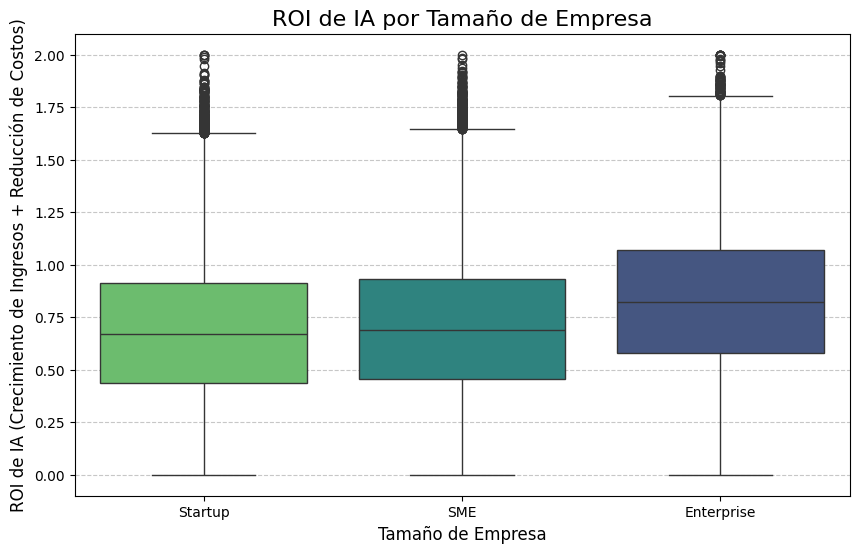

In [ ]:
# Definir el orden deseado para 'company_size'
company_size_order = ['Startup', 'SME', 'Enterprise']

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='company_size',
    y='roi_ai',
    data=df_ia,
    order=company_size_order, # Aplicar el orden personalizado
    palette='viridis',
    hue='company_size', # Asignar 'x' a 'hue' para la paleta
    legend=False # Desactivar la leyenda ya que el hue está en el eje x
)

plt.title('ROI de IA por Tamaño de Empresa', fontsize=16)
plt.xlabel('Tamaño de Empresa', fontsize=12)
plt.ylabel('ROI de IA (Crecimiento de Ingresos + Reducción de Costos)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()